# Compare $PKP^*$ and $PK$ during training


This notebook compares two operators from the global-state NTK factorization:

$$NTK = P K P^*.$$

Here $K$ is the local/core operator coming from immediate parameter-to-state interactions, and $P$ is the propagator that transports perturbations through the dynamics.

We compare the full NTK operator
$$
P K P^*
$$
with the one-sided operator
$$
P K,
$$
which can be viewed as a truncated-backprop / e-prop style approximation, since it omits the final adjoint propagation $P^*$.

At several GD snapshots during training, the notebook:

- constructs $P$, $K$, and the NTK,
- verifies that $P K P^*$ matches the NTK numerically,
- measures how aligned $P K$ is with the NTK, i.e. how much does truncation align with true GD.

So the basic question is: how much of the NTK geometry is already present in $P K$, so when can we use truncation?

In [1]:
import copy, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
import torch.nn.functional as F
from tqdm import tqdm
from torchvision import datasets, transforms

from kpflow.parameter_op import ParameterOperator as Kop
from kpflow.propagation_op import PropagationOperator_LinearForm as Pop
from kpflow.grad_op import HiddenNTKOperator as NTK
from kpflow.architecture import Model, BasicRNN, get_cell_from_model
from kpflow.op_common import MatrixWrapper as Mat, IdentityOperator as Id

In [2]:
def set_mpl_defaults(fontsize=13):
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    plt.rc('font', size=fontsize)
    plt.rc('axes', titlesize=fontsize)
    plt.rc('axes', labelsize=fontsize)
    plt.rc('xtick', labelsize=fontsize)
    plt.rc('ytick', labelsize=fontsize)
    plt.rc('legend', fontsize=fontsize)
    plt.rc('figure', titlesize=fontsize)
    mpl.rcParams['figure.dpi'] = 120

set_mpl_defaults()

## Data and model

In [3]:
bs = 200
T = 11
dev = "cuda" if torch.cuda.is_available() else "cpu"

tfm = transforms.ToTensor()
train = torch.utils.data.DataLoader(
    datasets.MNIST("./data", train=True, download=True, transform=tfm),
    batch_size=bs, shuffle=True
)
test = torch.utils.data.DataLoader(
    datasets.MNIST("./data", train=False, download=True, transform=tfm),
    batch_size=bs, shuffle=False
)

def process_inps(x, y):
    x, y = x.to(dev).float(), y.to(dev)
    x = x.reshape((x.shape[0], -1))
    return torch.stack(T * [x], 1), y

model = Model(28 * 28, 256, 10, rnn=BasicRNN, bias=False).to(dev)

## Train briefly and save a few GD snapshots

In [4]:
snapshot_steps = [0, 10, 50, 100, 200, 400]
snapshots = {}

optim = torch.optim.Adam(model.parameters(), lr=1e-2)

step = 0
snapshots[step] = copy.deepcopy(model.state_dict())
losses = []

if os.path.exists('model_learning_compare.pt'):
    model.load_state_dict(torch.load('model_learning_compare.pt', weights_only=True))
else:
    optim = torch.optim.Adam(model.parameters(), lr=1e-3)

    pbar = tqdm(range(5))
    step = 0
    for epoch in pbar:
        model.train()
        for x, y in train:
            x, y = process_inps(x, y)
            optim.zero_grad()
            loss = F.cross_entropy(model(x)[0][:, -1], y)
            loss.backward()
            optim.step()
            step += 1

            if step in snapshot_steps:
                snapshots[step] = copy.deepcopy(model.state_dict())

            if step >= max(snapshot_steps):
                break

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in test:
                x, y = process_inps(x, y)
                pred = model(x)[0][:, -1].argmax(-1)
                correct += (pred == y).sum().item()
                total += y.numel()
        pbar.set_description(f"epoch {epoch+1}: acc={correct/total:.4f}")

pbar.close()
print("saved snapshots:", sorted(snapshots.keys()))

epoch 5: acc=0.9526: 100%|██████████| 5/5 [00:19<00:00,  3.98s/it]

saved snapshots: [0, 10, 50, 100, 200, 400]


## Operator helpers

In [5]:
inps, targs = next(iter(test))
inps, targs = process_inps(inps, targs)

def build_ops(model, inps):
    from kpflow.op_common import MatrixWrapper as Mat
    cell = get_cell_from_model(model)
    hidd = model(inps)[1].detach().cpu()

    # Wrapper, extracting hidden state from model, which usally returns an (output, hidden state) pair
    class GetHidden(torch.nn.Module):
        def __init__(self, net):
            super().__init__()
            self.net = net

        def forward(self, x):
            return self.net(x)[1]


    kop = Kop(cell, inps, hidd, dev = dev)
    pop = Pop(cell, inps, hidd, dev = dev)
    ntk = NTK(GetHidden(model), inps, hidd, dev = dev)

    nx, nt, n = hidd.shape
    B = np.random.randn(n, n)
    bop = Mat(B, dev = dev).tprod_like(Id(nx*nt, dev = dev), kop)

    return dict(
        hidd=hidd,
        pop=pop,
        kop=kop,
        ntk=ntk,
        bop=bop,
        ntk_fact=pop @ kop @ pop.T,
        ep=pop @ kop,
        fa=pop @ bop @ pop.T
    )

In [13]:

def project(data):
    from sklearn.decomposition import PCA
    data_flat = data.reshape((-1, data.shape[-1]))
    ncomp = min(data_flat.shape)
    pca = PCA(ncomp).fit(data_flat) 
    return pca, pca.transform(data_flat).reshape((*data.shape[:-1], ncomp))

def plot_trajectories(data, m = 1, n = 1, i = 1, dim = 3, legend = True, c = None, cmap = None):
    # data should be shape [batch count, time, hidden dim].
    import matplotlib.pyplot as plt
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    plt.subplot(m, n, i, projection = None if dim == 2 else '3d')
    for idx, traj in enumerate(data):
        extra = {}
        if c is not None:
            extra['color'] = c[idx] if cmap is None else cmap((c[idx] - c.min()) / (c.max() - c.min()))

        if dim == 3:
            plt.plot(traj[:, 0], traj[:, 1], traj[:, 2], **extra)
            plt.gca().set_zlabel('PC3')
        else:
            plt.plot(traj[:, 0], traj[:, 1], **extra)
        plt.xlabel('PC1')
        plt.ylabel('PC2')

def plot_traj_mempro(ang, data, m = 1, n = 1, i = 1, dim = 3, legend = True, colors = None):
    # data should be shape [batch count, time, hidden dim].
    import matplotlib.pyplot as plt
    from matplotlib.colors import to_rgba
    PALLETTE = ['#f86969ff', '#7e69f8ff', '#f8c969ff', '#69f87cff', '#e569f8ff']
    plt.subplot(m, n, i, projection = None if dim == 2 else '3d')
    for idx, (traj, my_ang) in enumerate(zip(data, ang)):
        t = (my_ang + np.pi) / (2 * np.pi) * .4 + .6
        scale = lambda c : np.array(to_rgba(c)) * t
        if dim == 3:
            plt.plot(traj[:31, 0], traj[:31, 1], traj[:31, 2], color = scale(PALLETTE[0]))
            plt.plot(traj[30:61, 0], traj[30:61, 1], traj[30:61, 2], color = scale(PALLETTE[1]))
            plt.plot(traj[60:, 0], traj[60:, 1], traj[60:, 2], color = scale(PALLETTE[2]))
        else:
            plt.plot(traj[:31, 0], traj[:31, 1], color = scale(PALLETTE[0]))
            plt.plot(traj[30:61, 0], traj[30:61, 1], color = scale(PALLETTE[1]))
            plt.plot(traj[60:, 0], traj[60:, 1], color = scale(PALLETTE[2]))
    if legend:
        plt.legend(['stim', 'mem', 'resp'])


def projection(model, inps):
    from kpflow.op_common import MatrixWrapper as Mat
    cell = get_cell_from_model(model)
    hidd = model(inps)[1].detach().cpu()
    return project(hidd)[1]

## Compare $PKP^*$ vs $PK$

100%|██████████| 6/6 [00:02<00:00,  2.51it/s]


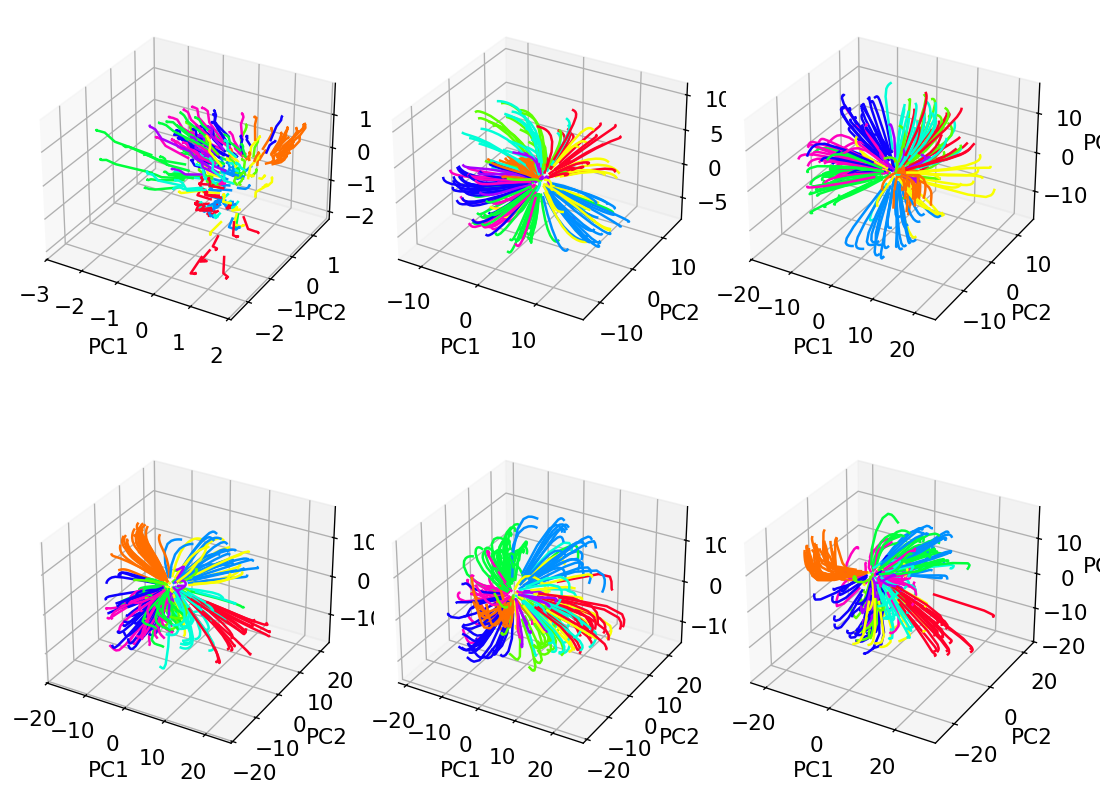

In [20]:
rows = []


plt.figure(figsize = (3 * 3, 4 * 2))
for idx, step in enumerate(tqdm(sorted(snapshots))):
    model.load_state_dict(snapshots[step])
    proj = projection(model, inps)

    plot_trajectories(proj, 2, 3, idx + 1, dim = 3, c = targs.detach().cpu().numpy(), cmap = 'gist_rainbow')

plt.tight_layout()

In [10]:
rows = []

for step in tqdm(sorted(snapshots)):
    model.load_state_dict(snapshots[step])
    ops = build_ops(model, inps)

    ntk = ops["ntk"]
    pop = ops["pop"]
    kop = ops["kop"]
    bop = ops["bop"]
    ntk_fact = ops["ntk_fact"]
    ep = ops["ep"]
    fa = ops["fa"]

    rows.append(dict(
        step=step,
        ntk_fact_compare=ntk_fact.compare(ntk),
        ntk_align_ntk_fact=ntk.alignment(ntk_fact),
        ntk_align_pk=ntk.alignment(ep),
        ntk_align_k=ntk.alignment(kop),
        ntk_align_fa=ntk.alignment(fa)
    ))

df = pd.DataFrame(rows)
df

  0%|          | 0/6 [00:00<?, ?it/s]

torch.Size([200])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x200 and 10x256)

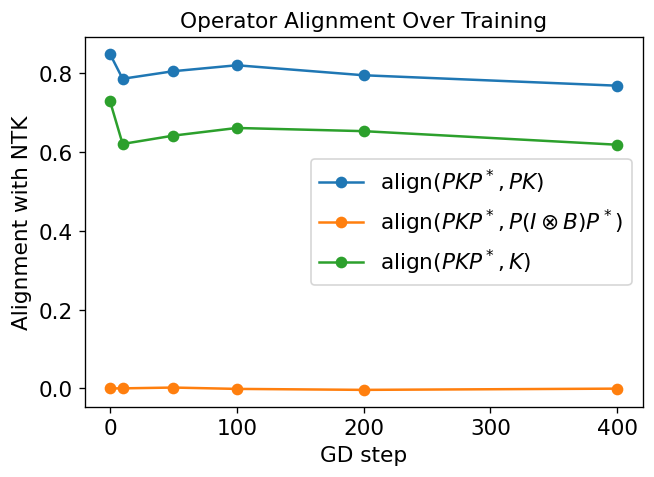

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df.step, df.ntk_align_pk, marker='o', label=r'$\mathrm{align}(PKP^*, PK)$')
ax.plot(df.step, df.ntk_align_fa, marker='o', label=r'$\mathrm{align}(PKP^*, P(I \otimes B)P^*)$')
ax.plot(df.step, df.ntk_align_k, marker='o', label=r'$\mathrm{align}(PKP^*, K)$')
ax.set_xlabel('GD step')
ax.set_ylabel('Alignment with NTK')
ax.legend()
ax.set_title('Operator Alignment Over Training')
plt.show()

# Verify NTK is truly equal to $P K P^*$, as in my paper, measuring max relative error over all snapshots:

In [28]:
print("max factorization error:", df.ntk_fact_compare.max())
df

max factorization error: tensor(5.1677e-08, device='cuda:0')


,step,ntk_fact_compare,ntk_align_ntk_fact,ntk_align_pk,ntk_align_k
0,0,"tensor(5.1677e-08, device='cuda:0')",1.0,0.715423,0.593153
1,10,"tensor(4.5403e-08, device='cuda:0')",1.0,0.713955,0.600962
2,50,"tensor(0., device='cuda:0')",1.0,0.724382,0.584831
3,100,"tensor(0., device='cuda:0')",1.0,0.691312,0.583994
4,200,"tensor(4.6877e-08, device='cuda:0')",1.0,0.703834,0.575168
5,400,"tensor(5.0209e-08, device='cuda:0')",1.0,0.703129,0.572165
